# Libraries

In [1]:
import pandas as pd

In [23]:
df_temperatura_baja = pd.read_csv('./inside data resampled/temperatura_baja.csv')
df_temperatura_baja['_time'] = pd.to_datetime(df_temperatura_baja['_time'])
df_temperatura_centro = pd.read_csv('./inside data resampled/temperatura_centro.csv')
df_temperatura_centro['_time'] = pd.to_datetime(df_temperatura_centro['_time'])

df_humedad_baja = pd.read_csv('./inside data resampled/humedad_baja.csv')
df_humedad_baja['_time'] = pd.to_datetime(df_humedad_baja['_time'])
df_humedad_centro = pd.read_csv('./inside data resampled/humedad_centro.csv')
df_humedad_centro['_time'] = pd.to_datetime(df_humedad_centro['_time'])


In [ ]:
df_precipitacion_exterior = pd.read_csv('./outside data resampled/precipitacion_exterior.csv')
df_precipitacion_exterior['_time'] = pd.to_datetime(df_precipitacion_exterior['_time'])
df_precipitacion_exterior.columns = ['_time','Outside_Precipitation']

df_temperatura_exterior = pd.read_csv('./outside data resampled/temperatura_exterior.csv')
df_temperatura_exterior['_time'] = pd.to_datetime(df_temperatura_exterior['_time'])
df_temperatura_exterior.columns = ['_time','Outside_Temperature']

df_humedad_exterior = pd.read_csv('./outside data resampled/humedad_exterior.csv')
df_humedad_exterior['_time'] = pd.to_datetime(df_humedad_exterior['_time'])
df_humedad_exterior.columns = ['_time','Outside_Humidity']

df_velocidad_viento_exterior = pd.read_csv('./outside data resampled/velocidad_viento_exterior.csv')
df_velocidad_viento_exterior['_time'] = pd.to_datetime(df_velocidad_viento_exterior['_time'])
df_velocidad_viento_exterior.columns = ['_time','Outside_WindSpeed']

df_par_exterior = pd.read_csv('./outside data resampled/par_exterior.csv')
df_par_exterior['_time'] = pd.to_datetime(df_par_exterior['_time'])
df_par_exterior.columns = ['_time','Outside_Par']

In [24]:
df_temperatura = pd.concat([df_temperatura_baja[df_temperatura_baja['_time'] < '2026-06-11 00:00:00'], 
                           df_temperatura_centro[df_temperatura_centro['_time'] >= '2026-06-11 00:00:00']]).reset_index(drop=True)
df_temperatura.columns = ['_time', 'Temperature']

df_humedad = pd.concat([df_humedad_baja[df_humedad_baja['_time'] < '2026-06-11 00:00:00'], 
                           df_humedad_centro[df_humedad_centro['_time'] >= '2026-06-11 00:00:00']]).reset_index(drop=True)
df_humedad.columns = ['_time', 'Humidity']

In [2]:
df_forecast = pd.read_csv('./forecast data/hourly_weather_data.csv')
df_forecast['date'] = pd.to_datetime(df_forecast['date'])
df_forecast = df_forecast[['date', 'temperature_2m_previous_day1', 'relative_humidity_2m_previous_day1', 'precipitation_previous_day1', 
       'wind_speed_10m_previous_day1', 'shortwave_radiation_previous_day1']]
df_forecast

,date,temperature_2m_previous_day1,relative_humidity_2m_previous_day1,precipitation_previous_day1,wind_speed_10m_previous_day1,shortwave_radiation_previous_day1
0,2025-12-31 23:00:00,6.45,92.036910,0.0,0.430116,0.0
1,2026-01-01 00:00:00,6.35,92.351260,0.0,0.650000,0.0
2,2026-01-01 01:00:00,6.50,93.650500,0.0,0.694622,0.0
3,2026-01-01 02:00:00,5.95,95.265500,0.0,0.901388,0.0
4,2026-01-01 03:00:00,5.05,98.960860,0.0,1.101136,0.0
...,...,...,...,...,...,...
4651,2026-07-13 19:00:00,36.45,32.388218,0.0,3.252691,441.0
4652,2026-07-13 20:00:00,35.20,32.357082,0.0,3.460130,272.0
4653,2026-07-13 21:00:00,32.15,39.117195,0.0,3.696282,102.0
4654,2026-07-13 22:00:00,29.90,39.122993,0.0,2.294014,6.0


In [64]:
from functools import reduce

dfs = [
    df_temperatura.rename(columns={'_time': 'date'}),
    df_humedad.rename(columns={'_time': 'date'}),
    df_precipitacion_exterior.rename(columns={'_time': 'date'}),
    df_temperatura_exterior.rename(columns={'_time': 'date'}),
    df_humedad_exterior.rename(columns={'_time': 'date'}),
    df_velocidad_viento_exterior.rename(columns={'_time': 'date'}),
    df_par_exterior.rename(columns={'_time': 'date'}),
    df_forecast.copy()
]

df_merged = reduce(lambda left, right: pd.merge(left, right, on='date', how='inner'), dfs)
df_merged

,date,Temperature,Humidity,Outside_Precipitation,Outside_Temperature,Outside_Humidity,Outside_WindSpeed,Outside_Par,temperature_2m_previous_day1,relative_humidity_2m_previous_day1,precipitation_previous_day1,wind_speed_10m_previous_day1,shortwave_radiation_previous_day1
0,2026-01-04 08:00:00,11.311111,93.000000,0.7,12.125833,85.263333,0.422483,23.093333,8.15,95.999115,0.1,1.308625,0.0
1,2026-01-04 09:00:00,12.387500,92.047619,0.4,12.400833,85.656667,0.735612,15.648333,8.65,95.689010,0.0,0.934077,6.0
2,2026-01-04 10:00:00,13.377143,90.800000,0.0,12.610000,85.395833,1.352857,56.482500,9.60,93.800740,0.0,1.710263,46.0
3,2026-01-04 11:00:00,14.755556,86.000000,0.0,12.717500,84.990833,1.814956,61.891667,10.75,92.915960,0.0,1.526434,95.0
4,2026-01-04 12:00:00,16.479545,82.550000,0.0,13.308333,84.605833,1.787018,89.897500,11.35,92.948220,0.0,1.202081,80.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
3719,2026-06-08 08:00:00,28.523864,58.617978,0.0,27.202500,59.738333,1.170718,333.953333,20.50,60.712650,0.0,1.350926,77.0
3720,2026-06-08 09:00:00,28.807595,53.988506,0.0,28.360000,56.363333,1.586054,427.109167,23.40,48.902798,0.0,0.750000,245.0
3721,2026-06-08 10:00:00,29.994253,50.989130,0.0,29.906667,52.406667,1.754661,499.140833,25.75,43.194600,0.0,0.364005,437.0
3722,2026-06-08 11:00:00,31.456627,52.980952,0.0,31.330000,49.745833,2.078286,541.702500,27.70,38.007460,0.0,0.806226,620.0


## Data Preparation for LSTM Models

In [ ]:
import numpy as np
import random
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.ensemble import RandomForestRegressor
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

In [66]:
# Sort the dataframe by date to ensure proper time series ordering
df_merged = df_merged.sort_values('date').reset_index(drop=True)
print(f"DataFrame shape: {df_merged.shape}")
print(f"Date range: {df_merged['date'].min()} to {df_merged['date'].max()}")
print(f"\nDataFrame columns:\n{df_merged.columns.tolist()}")
print(f"\nFirst few rows:\n{df_merged.head()}")

DataFrame shape: (3724, 13)
Date range: 2026-01-04 08:00:00 to 2026-06-08 12:00:00

DataFrame columns:
['date', 'Temperature', 'Humidity', 'Outside_Precipitation', 'Outside_Temperature', 'Outside_Humidity', 'Outside_WindSpeed', 'Outside_Par', 'temperature_2m_previous_day1', 'relative_humidity_2m_previous_day1', 'precipitation_previous_day1', 'wind_speed_10m_previous_day1', 'shortwave_radiation_previous_day1']

First few rows:
                 date  Temperature   Humidity  Outside_Precipitation  \
0 2026-01-04 08:00:00    11.311111  93.000000                    0.7   
1 2026-01-04 09:00:00    12.387500  92.047619                    0.4   
2 2026-01-04 10:00:00    13.377143  90.800000                    0.0   
3 2026-01-04 11:00:00    14.755556  86.000000                    0.0   
4 2026-01-04 12:00:00    16.479545  82.550000                    0.0   

   Outside_Temperature  Outside_Humidity  Outside_WindSpeed  Outside_Par  \
0            12.125833         85.263333           0.422483  

In [67]:
# Check for missing values and handle them
print(f"Missing values:\n{df_merged.isnull().sum()}")

# Drop rows with missing values (you can also use interpolation if preferred)
df_merged = df_merged.dropna().reset_index(drop=True)
print(f"\nDataFrame shape after removing NaNs: {df_merged.shape}")

Missing values:
date                                    0
Temperature                           143
Humidity                              143
Outside_Precipitation                   0
Outside_Temperature                    13
Outside_Humidity                       13
Outside_WindSpeed                     231
Outside_Par                            13
temperature_2m_previous_day1          366
relative_humidity_2m_previous_day1    366
precipitation_previous_day1             0
wind_speed_10m_previous_day1          263
shortwave_radiation_previous_day1       0
dtype: int64

DataFrame shape after removing NaNs: (3006, 13)


In [68]:
# Extract features for input to LSTM (all columns except date)
# Include both inside and outside weather variables, plus forecast data
feature_columns = [col for col in df_merged.columns if col != 'date']
data = df_merged[feature_columns].values

# Normalize the data using StandardScaler
scaler = StandardScaler()
data_scaled = scaler.fit_transform(data)

print(f"Feature columns: {feature_columns}")
print(f"Scaled data shape: {data_scaled.shape}")

# Identify column indices for Temperature and Humidity targets
target_cols = {'Temperature': feature_columns.index('Temperature') if 'Temperature' in feature_columns else None,
               'Humidity': feature_columns.index('Humidity') if 'Humidity' in feature_columns else None}
print(f"\nTarget column indices: {target_cols}")

Feature columns: ['Temperature', 'Humidity', 'Outside_Precipitation', 'Outside_Temperature', 'Outside_Humidity', 'Outside_WindSpeed', 'Outside_Par', 'temperature_2m_previous_day1', 'relative_humidity_2m_previous_day1', 'precipitation_previous_day1', 'wind_speed_10m_previous_day1', 'shortwave_radiation_previous_day1']
Scaled data shape: (3006, 12)

Target column indices: {'Temperature': 0, 'Humidity': 1}


In [69]:
def create_sequences(data, target_indices, lookback=24, horizons=[1, 6, 12]):
    """
    Create sequences for LSTM training with multiple prediction horizons
    
    Parameters:
    -----------
    data : array-like
        Scaled input data
    target_indices : list
        Column indices of `data` to use as prediction targets (e.g. Temperature, Humidity)
    lookback : int
        Number of previous timesteps to use as input variables
    horizons : list
        List of prediction horizons (in hours)
    
    Returns:
    --------
    X : array
        Input sequences of shape (samples, lookback, features)
    y_dict : dict
        Dictionary with targets for each horizon
    """
    X = []
    y_dict = {h: [] for h in horizons}
    
    # Calculate the maximum index we can start from
    # We need: i + lookback + max(horizon) - 1 < len(data)
    max_i = len(data) - lookback - max(horizons)
    
    if max_i < 0:
        raise ValueError(f"Data is too short for the given lookback ({lookback}) and horizons ({horizons}). "
                        f"Need at least {lookback + max(horizons)} samples, but got {len(data)}.")
    
    for i in range(max_i + 1):
        # Create input sequence (lookback window)
        X.append(data[i:i + lookback, :])
        
        # Create targets for each horizon
        for horizon in horizons:
            # Get the target at the specified horizon ahead
            target_idx = i + lookback + horizon - 1
            y_dict[horizon].append(data[target_idx, target_indices])
    
    X = np.array(X)
    
    # Convert targets to arrays
    for h in horizons:
        y_dict[h] = np.array(y_dict[h])
    
    return X, y_dict

In [70]:
# Parameters
lookback = 24  # Use 24 hours of history
horizons = [1, 6, 12]  # Prediction horizons in hours

# Create sequences (targets are Temperature and Humidity only)
target_indices = [target_cols['Temperature'], target_cols['Humidity']]
X, y_dict = create_sequences(data_scaled, target_indices, lookback=lookback, horizons=horizons)

print(f"Input sequence shape (X): {X.shape}")
print(f"Lookback window: {lookback} hours")
print(f"Prediction horizons: {horizons} hours")
for h in horizons:
    print(f"Target shape for {h}-hour horizon: {y_dict[h].shape}")

Input sequence shape (X): (2971, 24, 12)
Lookback window: 24 hours
Prediction horizons: [1, 6, 12] hours
Target shape for 1-hour horizon: (2971, 2)
Target shape for 6-hour horizon: (2971, 2)
Target shape for 12-hour horizon: (2971, 2)


In [71]:
# Train-Test Split (80-20 split)
train_size = int(len(X) * 0.8)
test_size = len(X) - train_size

X_train = X[:train_size]
X_test = X[train_size:]

# Split targets for each horizon
y_train = {}
y_test = {}
for h in horizons:
    y_train[h] = y_dict[h][:train_size]
    y_test[h] = y_dict[h][train_size:]

print(f"Training set size: {len(X_train)}")
print(f"Test set size: {len(X_test)}")
print(f"Training-Test split: {train_size}/{test_size}")

Training set size: 2376
Test set size: 595
Training-Test split: 2376/595


## Building and Training LSTM Models

In [77]:
SEED = 42
np.random.seed(SEED)
random.seed(SEED)
tf.keras.utils.set_random_seed(SEED)

def build_lstm_model(input_shape, num_features):
    """
    Build an LSTM model for multi-variate time series prediction
    
    Parameters:
    -----------
    input_shape : tuple
        Shape of input (lookback, num_features)
    num_features : int
        Number of output features to predict
    
    Returns:
    --------
    model : Keras Sequential model
    """
    model = Sequential([
        LSTM(64, activation='tanh', return_sequences=True, input_shape=input_shape),
        Dropout(0.2),
        LSTM(32, activation='tanh', return_sequences=False),
        Dropout(0.2),
        Dense(16, activation='tanh'),
        Dense(num_features)
    ])
    
    model.compile(optimizer=Adam(learning_rate=0.001), loss='mse', metrics=['mae'])
    return model

# Build and train models for each horizon
models = {}
histories = {}

for horizon in horizons:
    print(f"\n{'='*60}")
    print(f"Training LSTM model for {horizon}-hour horizon")
    print(f"{'='*60}")
    
    # Build model
    model = build_lstm_model((X_train.shape[1], X_train.shape[2]), y_train[horizon].shape[1])
    print(f"\nModel architecture:")
    model.summary()
    
    # Train model
    history = model.fit(
        X_train, y_train[horizon],
        epochs=150,
        batch_size=64,
        validation_split=0.2,
        verbose=0,
        callbacks=EarlyStopping(monitor='val_loss', patience=8, restore_best_weights=True)
    )

    models[horizon] = model
    histories[horizon] = history

print("\n" + "="*60)
print("All models trained successfully!")
print("="*60)


Training LSTM model for 1-hour horizon

Model architecture:


Model: "sequential_13"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_26 (LSTM)                  │ (None, 24, 64)         │        19,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_26 (Dropout)            │ (None, 24, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_27 (LSTM)                  │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_27 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_26 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_27 (Dense)                │ (None, 2)              │            34 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 32,690 (127.70 KB)

 Trainable params: 32,690 (127.70 KB)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_30 (LSTM)                  │ (None, 24, 64)         │        19,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_30 (Dropout)            │ (None, 24, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_31 (LSTM)                  │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_31 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_30 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_31 (Dense)                │ (None, 2)              │            34 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 32,690 (127.70 KB)

 Trainable params: 32,690 (127.70 KB)

 Non-trainable params: 0 (0.00 B)


All models trained successfully!


## Model Evaluation and Results

In [81]:
# Make predictions on test set and evaluate
predictions = {}
metrics_results = {}

# Column indices for Temperature and Humidity
temp_idx = target_cols['Temperature']
humid_idx = target_cols['Humidity']

print("Evaluating LSTM Models on Test Set")

for horizon in horizons:
    print(f"\n{horizon}-Hour Prediction Horizon")
    
    # Make predictions
    y_pred_scaled = models[horizon].predict(X_test, verbose=0)
    
    # Inverse transform to original scale
    # Place the 2-column (Temperature, Humidity) predictions into a full-width zero array
    y_pred_full = np.zeros((len(y_pred_scaled), data.shape[1]))
    y_test_full = np.zeros((len(y_test[horizon]), data.shape[1]))
    
    y_pred_full[:, target_indices] = y_pred_scaled
    y_test_full[:, target_indices] = y_test[horizon]
    
    y_pred = scaler.inverse_transform(y_pred_full)
    y_test_actual = scaler.inverse_transform(y_test_full)
    
    predictions[horizon] = {
        'predictions': y_pred,
        'actual': y_test_actual,
        'scaled_predictions': y_pred_scaled
    }
    
    # Calculate metrics for Temperature
    mse_temp = mean_squared_error(y_test_actual[:, temp_idx], y_pred[:, temp_idx])
    mae_temp = mean_absolute_error(y_test_actual[:, temp_idx], y_pred[:, temp_idx])
    r2_temp = np.corrcoef(y_test_actual[:, temp_idx], y_pred[:, temp_idx])[0][1]**2
    rmse_temp = np.sqrt(mse_temp)
    cvrmse_temp = rmse_temp/np.mean(y_test_actual[:, temp_idx])*100
    
    # Calculate metrics for Humidity
    mse_humid = mean_squared_error(y_test_actual[:, humid_idx], y_pred[:, humid_idx])
    mae_humid = mean_absolute_error(y_test_actual[:, humid_idx], y_pred[:, humid_idx])
    r2_humid = np.corrcoef(y_test_actual[:, humid_idx], y_pred[:, humid_idx])[0][1]**2
    rmse_humid = np.sqrt(mse_humid)
    cvrmse_humid = rmse_humid/np.mean(y_test_actual[:, humid_idx])*100
    
    metrics_results[horizon] = {
        'Temperature': {'MSE': mse_temp, 'RMSE': rmse_temp, 'MAE': mae_temp, 'R2': r2_temp},
        'Humidity': {'MSE': mse_humid, 'RMSE': rmse_humid, 'MAE': mae_humid, 'R2': r2_humid}
    }
    
    print(f"\nTemperature Predictions:")
    print(f"  CVRMSE:  {cvrmse_temp:.4f}")
    print(f"  RMSE: {rmse_temp:.4f}")
    print(f"  MAE:  {mae_temp:.4f}")
    print(f"  R²:   {r2_temp:.4f}")
    
    print(f"\nHumidity Predictions:")
    print(f"  CVRMSE:  {cvrmse_humid:.4f}")
    print(f"  RMSE: {rmse_humid:.4f}")
    print(f"  MAE:  {mae_humid:.4f}")
    print(f"  R²:   {r2_humid:.4f}")


Evaluating LSTM Models on Test Set

1-Hour Prediction Horizon

Temperature Predictions:
  CVRMSE:  15.4062
  RMSE: 3.9683
  MAE:  2.8727
  R²:   0.7517

Humidity Predictions:
  CVRMSE:  19.5466
  RMSE: 11.2833
  MAE:  8.4581
  R²:   0.6532

6-Hour Prediction Horizon

Temperature Predictions:
  CVRMSE:  34.4978
  RMSE: 8.8885
  MAE:  7.7971
  R²:   0.4130

Humidity Predictions:
  CVRMSE:  19.7890
  RMSE: 11.4590
  MAE:  8.9314
  R²:   0.4825

12-Hour Prediction Horizon

Temperature Predictions:
  CVRMSE:  18.9482
  RMSE: 4.9042
  MAE:  3.7717
  R²:   0.4728

Humidity Predictions:
  CVRMSE:  24.5663
  RMSE: 14.2148
  MAE:  11.7822
  R²:   0.5100


In [75]:
# Stronger alternative baseline: Random Forest for comparison
# Build a feature matrix from the lagged history for each sample
X_rf = X.reshape(X.shape[0], -1)

# Use one RF model per horizon, matching the LSTM output dimensionality
rf_results = {}

for horizon in horizons:
    X_rf_train = X_rf[:train_size]
    X_rf_test = X_rf[train_size:]
    y_rf_train = y_train[horizon]
    y_rf_test = y_test[horizon]

    rf_model = RandomForestRegressor(
        n_estimators=300,
        random_state=SEED,
        max_depth=None,
        min_samples_leaf=2,
        n_jobs=-1
    )
    rf_model.fit(X_rf_train, y_rf_train)
    rf_pred = rf_model.predict(X_rf_test)

    # Inverse transform to original scale (place 2-col predictions into a full-width zero array)
    rf_pred_full = np.zeros((len(rf_pred), data.shape[1]))
    rf_test_full = np.zeros((len(y_rf_test), data.shape[1]))
    rf_pred_full[:, target_indices] = rf_pred
    rf_test_full[:, target_indices] = y_rf_test
    rf_pred_orig = scaler.inverse_transform(rf_pred_full)
    rf_test_orig = scaler.inverse_transform(rf_test_full)

    # Calculate metrics for Temperature
    mse_temp = mean_squared_error(rf_test_orig[:, temp_idx], rf_pred_orig[:, temp_idx])
    mae_temp = mean_absolute_error(rf_test_orig[:, temp_idx], rf_pred_orig[:, temp_idx])
    r2_temp = np.corrcoef(rf_test_orig[:, temp_idx], rf_pred_orig[:, temp_idx])[0][1]**2
    rmse_temp = np.sqrt(mse_temp)
    cvrmse_temp = rmse_temp/np.mean(rf_test_orig[:, temp_idx])*100

    # Calculate metrics for Humidity
    mse_humid = mean_squared_error(rf_test_orig[:, humid_idx], rf_pred_orig[:, humid_idx])
    mae_humid = mean_absolute_error(rf_test_orig[:, humid_idx], rf_pred_orig[:, humid_idx])
    r2_humid = np.corrcoef(rf_test_orig[:, humid_idx], rf_pred_orig[:, humid_idx])[0][1]**2
    rmse_humid = np.sqrt(mse_humid)
    cvrmse_humid = rmse_humid/np.mean(rf_test_orig[:, humid_idx])*100

    rf_results[horizon] = {
        'Temperature': {'MSE': mse_temp, 'RMSE': rmse_temp, 'MAE': mae_temp, 'R2': r2_temp, 'CVRMSE': cvrmse_temp},
        'Humidity': {'MSE': mse_humid, 'RMSE': rmse_humid, 'MAE': mae_humid, 'R2': r2_humid, 'CVRMSE': cvrmse_humid}
    }

    print(f'Random Forest baseline - {horizon}h horizon')
    print(f'\nTemperature Predictions:')
    print(f'  CVRMSE:  {cvrmse_temp:.4f}')
    print(f'  RMSE: {rmse_temp:.4f}')
    print(f'  MAE:  {mae_temp:.4f}')
    print(f'  R²:   {r2_temp:.4f}')

    print(f'\nHumidity Predictions:')
    print(f'  CVRMSE:  {cvrmse_humid:.4f}')
    print(f'  RMSE: {rmse_humid:.4f}')
    print(f'  MAE:  {mae_humid:.4f}')
    print(f'  R²:   {r2_humid:.4f}\n')

Random Forest baseline - 1h horizon

Temperature Predictions:
  CVRMSE:  9.4637
  RMSE: 2.4377
  MAE:  1.9202
  R²:   0.9143

Humidity Predictions:
  CVRMSE:  21.3141
  RMSE: 12.3036
  MAE:  8.8160
  R²:   0.6200

Random Forest baseline - 6h horizon

Temperature Predictions:
  CVRMSE:  16.8605
  RMSE: 4.3442
  MAE:  3.5126
  R²:   0.7754

Humidity Predictions:
  CVRMSE:  20.3908
  RMSE: 11.8075
  MAE:  9.6148
  R²:   0.5252

Random Forest baseline - 12h horizon

Temperature Predictions:
  CVRMSE:  16.0649
  RMSE: 4.1580
  MAE:  3.3063
  R²:   0.7613

Humidity Predictions:
  CVRMSE:  23.1598
  RMSE: 13.4009
  MAE:  10.8505
  R²:   0.4137



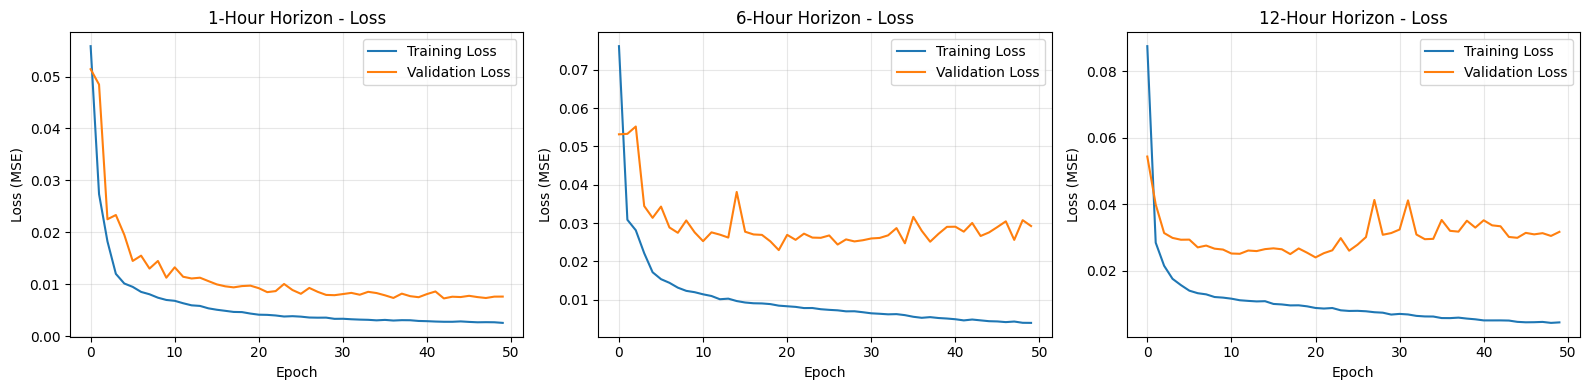

Training history plotted for all horizons


In [48]:
# Visualize training history for each model
fig, axes = plt.subplots(1, len(horizons), figsize=(16, 4))

for idx, horizon in enumerate(horizons):
    axes[idx].plot(histories[horizon].history['loss'], label='Training Loss')
    axes[idx].plot(histories[horizon].history['val_loss'], label='Validation Loss')
    axes[idx].set_title(f'{horizon}-Hour Horizon - Loss')
    axes[idx].set_xlabel('Epoch')
    axes[idx].set_ylabel('Loss (MSE)')
    axes[idx].legend()
    axes[idx].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("Training history plotted for all horizons")

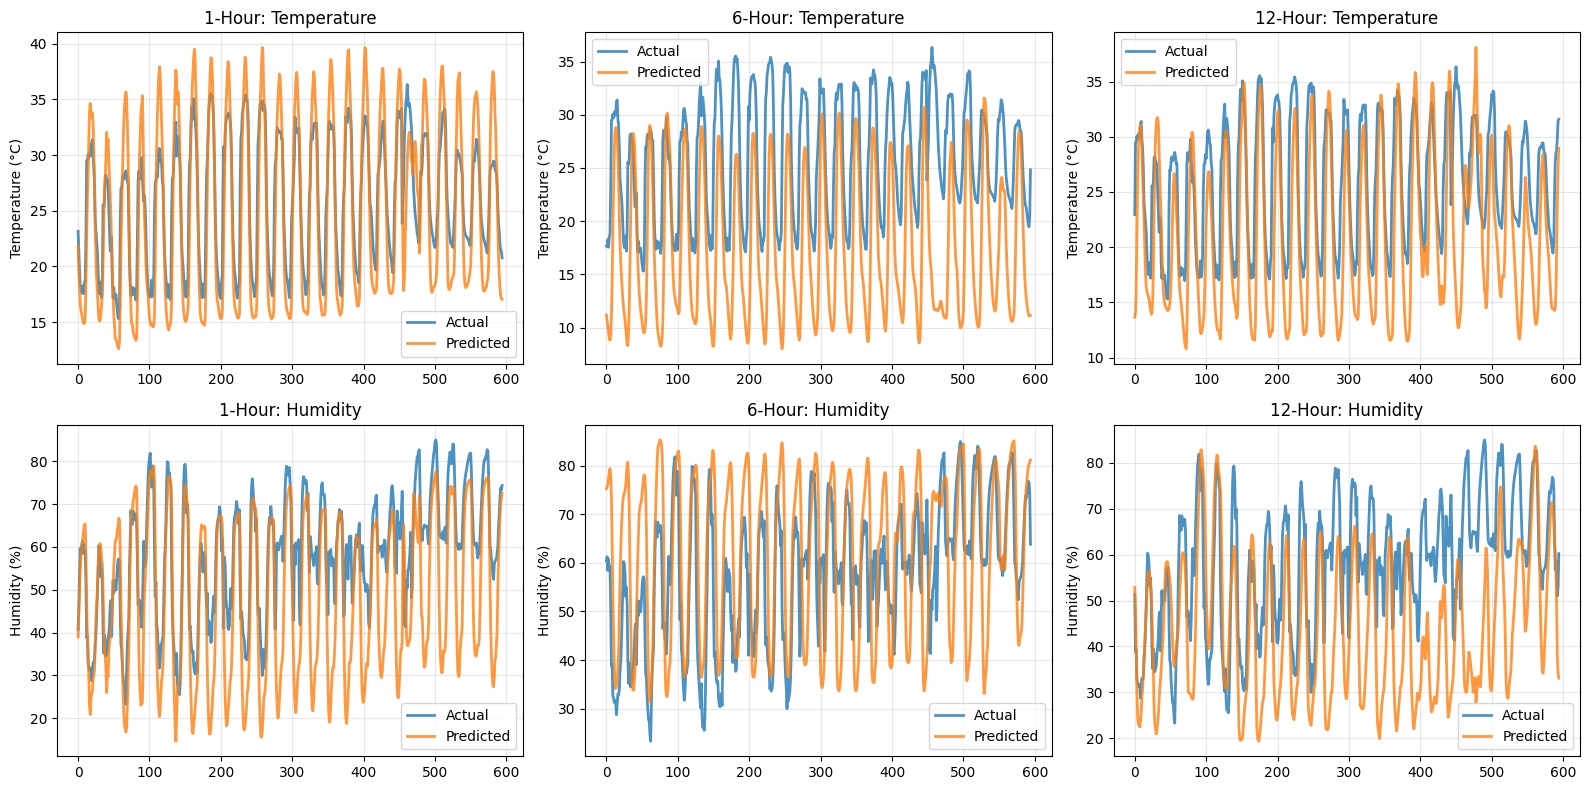

Predictions vs actual values plotted for all horizons


In [49]:
# Visualize predictions vs actual values
fig, axes = plt.subplots(2, len(horizons), figsize=(16, 8))

for idx, horizon in enumerate(horizons):
    y_pred = predictions[horizon]['predictions']
    y_actual = predictions[horizon]['actual']
    
    # Plot Temperature
    axes[0, idx].plot(y_actual[:, temp_idx], label='Actual', linewidth=2, alpha=0.8)
    axes[0, idx].plot(y_pred[:, temp_idx], label='Predicted', linewidth=2, alpha=0.8)
    axes[0, idx].set_title(f'{horizon}-Hour: Temperature')
    axes[0, idx].set_ylabel('Temperature (°C)')
    axes[0, idx].legend()
    axes[0, idx].grid(True, alpha=0.3)
    
    # Plot Humidity
    axes[1, idx].plot(y_actual[:, humid_idx], label='Actual', linewidth=2, alpha=0.8)
    axes[1, idx].plot(y_pred[:, humid_idx], label='Predicted', linewidth=2, alpha=0.8)
    axes[1, idx].set_title(f'{horizon}-Hour: Humidity')
    axes[1, idx].set_ylabel('Humidity (%)')
    axes[1, idx].legend()
    axes[1, idx].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("Predictions vs actual values plotted for all horizons")

## Save Models and Scaler

In [ ]:
import os
import pickle

# Create models directory if it doesn't exist
models_dir = './trained_models'
os.makedirs(models_dir, exist_ok=True)

# Save each model
for horizon in horizons:
    model_path = os.path.join(models_dir, f'lstm_model_{horizon}h_horizon.keras')
    models[horizon].save(model_path)
    print(f"Model for {horizon}-hour horizon saved to {model_path}")

# Save the scaler for future predictions
scaler_path = os.path.join(models_dir, 'scaler.pkl')
with open(scaler_path, 'wb') as f:
    pickle.dump(scaler, f)
print(f"\nScaler saved to {scaler_path}")

# Save feature names for reference
features_path = os.path.join(models_dir, 'feature_names.pkl')
with open(features_path, 'wb') as f:
    pickle.dump(feature_columns, f)
print(f"Feature names saved to {features_path}")

# Create a summary file
summary_path = os.path.join(models_dir, 'model_summary.txt')
with open(summary_path, 'w') as f:
    f.write("LSTM Models Summary\n")
    f.write("="*80 + "\n\n")
    f.write(f"Lookback window: {lookback} hours\n")
    f.write(f"Prediction horizons: {horizons} hours\n")
    f.write(f"Training set size: {len(X_train)}\n")
    f.write(f"Test set size: {len(X_test)}\n\n")
    f.write(f"Feature columns ({len(feature_columns)}):\n")
    for i, col in enumerate(feature_columns):
        f.write(f"  {i}: {col}\n")
    f.write("\n" + "="*80 + "\n")
    f.write("Performance Metrics\n")
    f.write("="*80 + "\n\n")
    
    for horizon in horizons:
        f.write(f"\n{horizon}-Hour Prediction Horizon\n")
        f.write("-"*80 + "\n")
        f.write(f"Temperature: RMSE={metrics_results[horizon]['Temperature']['RMSE']:.4f}, MAE={metrics_results[horizon]['Temperature']['MAE']:.4f}, R²={metrics_results[horizon]['Temperature']['R2']:.4f}\n")
        f.write(f"Humidity:    RMSE={metrics_results[horizon]['Humidity']['RMSE']:.4f}, MAE={metrics_results[horizon]['Humidity']['MAE']:.4f}, R²={metrics_results[horizon]['Humidity']['R2']:.4f}\n")

print(f"Model summary saved to {summary_path}")

## Making Future Predictions

In [ ]:
def predict_future(new_data, lookback=24, horizons=[1, 6, 12]):
    """
    Make predictions for new data using trained LSTM models
    
    Parameters:
    -----------
    new_data : array-like
        New data to make predictions from, shape (lookback, num_features)
    lookback : int
        Number of previous timesteps used in the model
    horizons : list
        List of horizons for which to make predictions
    
    Returns:
    --------
    predictions_dict : dict
        Dictionary with predictions for each horizon
    """
    # Ensure input data is the right shape
    if new_data.shape[0] != lookback:
        raise ValueError(f"Input data must have {lookback} timesteps")
    
    # Scale the data
    new_data_scaled = scaler.transform(new_data)
    
    # Add batch dimension
    X_new = np.array([new_data_scaled])
    
    predictions_dict = {}
    
    for horizon in horizons:
        # Make prediction
        y_pred_scaled = models[horizon].predict(X_new, verbose=0)[0]
        
        # Inverse transform (place 2-col prediction into a full-width zero array)
        y_pred_full = np.zeros((1, data.shape[1]))
        y_pred_full[0, target_indices] = y_pred_scaled
        y_pred = scaler.inverse_transform(y_pred_full)[0]
        
        predictions_dict[horizon] = {
            'Temperature': y_pred[temp_idx],
            'Humidity': y_pred[humid_idx],
            'Full_output': y_pred
        }
    
    return predictions_dict

# Example: Make predictions using the last lookback samples from the test set
print("Example prediction using the last 24 samples from test set:\n")
new_data_example = df_merged[feature_columns].iloc[-lookback:].values
predictions_example = predict_future(new_data_example)

for horizon in horizons:
    print(f"{horizon}-Hour Prediction:")
    print(f"  Temperature: {predictions_example[horizon]['Temperature']:.2f}°C")
    print(f"  Humidity: {predictions_example[horizon]['Humidity']:.2f}%\n")